# Install and import

In [ ]:
!pip install torch_geometric

In [ ]:
import pandas as pd
import numpy as np

import torch
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, EdgePooling
from torch_geometric.loader import DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import gc

# Preprocess

In [ ]:
cap_names = ["10", "11", "12", "15", "15-2", "15-3", "16", "16-2", "16-3", "17", "18", "18-2", "19"]

for i in cap_names:
  capturas = {}
  #cap = pd.read_csv(f"/content/unzipped_files/capture201108{str(i)}.csv", dtype={'Sport': object, 'Dport': object})
  cap = pd.read_csv(f"capture201108{str(i)}.csv", dtype={'Sport': object, 'Dport': object})
  cap_copy = cap.copy()
  #
  cap = cap.loc[(cap['Proto'] == "tcp") | (cap['Proto'] == "udp")]
  #
  keep_columns = [0,1,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
  cap = cap.iloc[:, keep_columns]
  #
  cap_norm = cap[~cap['Label'].str.contains("From-Botnet")].copy()
  cap_norm['Label'] = cap_norm['Label'].str.contains('From-Botnet').astype(int)
  #
  cap_bot = cap[cap['Label'].str.contains("From-Botnet")].copy()
  cap_bot['Label'] = cap_bot['Label'].str.contains('From-Botnet').astype(int)
  #
  aux_bot=cap_bot.groupby(['SrcAddr', 'DstAddr']).agg({
    'Dur': 'mean',
    'TotPkts': 'mean',
    'TotBytes': 'mean',
    'TotAppByte': 'mean',
    'Rate': 'mean',
    'Label': 'max'
  }).reset_index()
  num_rows = 2*len(aux_bot)
  #
  capturas["original"] = cap_copy
  capturas["filter"] = cap
  capturas["normal"] = cap_norm
  capturas["bot"] = cap_bot
  #
  for j in range(30):
    np.random.seed(42+j*10)
    cap_subset = pd.concat([cap_bot, cap_norm.sample(n=num_rows)]).sample(frac=1).reset_index(drop=True)
    capturas[f"cap_subset_{j:02}"] = cap_subset
  #
  del cap, cap_copy, cap_norm, cap_bot, aux_bot, cap_subset
  with open(f'capturas_{str(i)}.pkl', 'wb') as archivo:
    pickle.dump(capturas, archivo)
  #
  gc.collect()

In [ ]:
# SUBSETS POR CORRIDA

cap_names = ["10", "11", "12", "15", "15-2", "15-3", "16", "16-2", "16-3", "17", "18", "18-2", "19"]

for j in range(30):
  subsets = {}
  for i in cap_names:
    subsets[str(i)] = {}
    #
    with open(f'capturas_pkl/capturas_{str(i)}.pkl', 'rb') as archivo:
      capturas = pickle.load(archivo)
    #
    # Get all unique IPs from SrcAddr and DstAddr
    unique_ips = pd.unique(capturas[f"cap_subset_{j:02}"][['SrcAddr', 'DstAddr']].values.ravel('K'))
    # Create a mapping from IP address to a unique node index
    ip_to_index = {ip: idx for idx, ip in enumerate(unique_ips)}
    #
    # Group by SrcAddr to calculate sending-related features
    src_features = capturas[f"cap_subset_{j:02}"].groupby('SrcAddr').agg({
        'SrcPkts': 'mean',
        'SrcBytes': 'mean',
        'SAppBytes': 'mean',
        'SrcRate': 'mean'
    }).reset_index()
    # Add missing columns with zeros for nodes that do not appear as SrcAddr
    src_features = src_features.set_index('SrcAddr').reindex(unique_ips, fill_value=0).reset_index()
    #
    # Group by DstAddr to calculate receiving-related features
    dst_features = capturas[f"cap_subset_{j:02}"].groupby('DstAddr').agg({
        'DstPkts': 'mean',
        'DstBytes': 'mean',
        'DAppBytes': 'mean',
        'DstRate': 'mean'
    }).reset_index()
    # Add missing columns with zeros for nodes that do not appear as DstAddr
    dst_features = dst_features.set_index('DstAddr').reindex(unique_ips, fill_value=0).reset_index()
    #
    # Merge src_features and dst_features based on unique IPs
    node_features = pd.merge(src_features, dst_features, left_on='SrcAddr', right_on='DstAddr', how='outer')#.fillna(0)
    # Reorganize columns to create the final node feature vector:
    # [SrcPkts, SrcBytes, SAppBytes, SrcRate, DstPkts, DstBytes, DAppBytes, DstRate]
    node_features = node_features[['SrcPkts', 'SrcBytes', 'SAppBytes', 'SrcRate', 'DstPkts', 'DstBytes', 'DAppBytes', 'DstRate']]
    # Convert node features to tensor
    node_features_tensor = torch.tensor(node_features.values, dtype=torch.float)
    #
    # Group by SrcAddr and DstAddr to create edge features
    edge_features = capturas[f"cap_subset_{j:02}"].groupby(['SrcAddr', 'DstAddr']).agg({
        'Dur': 'mean',
        'TotPkts': 'mean',
        'TotBytes': 'mean',
        'TotAppByte': 'mean',
        'Rate': 'mean',
        'Label': 'max'
    }).reset_index()
    # Convert the SrcAddr and DstAddr pairs to edge indices
    edge_indices = torch.tensor([[ip_to_index[src], ip_to_index[dst]] for src, dst in zip(edge_features['SrcAddr'], edge_features['DstAddr'])], dtype=torch.long).t().contiguous()
    # Convert edge features to tensor
    edge_features_tensor = torch.tensor(edge_features[['Dur', 'TotPkts', 'TotBytes', 'TotAppByte', 'Rate']].values, dtype=torch.float)
    # Convert edge labels to tensor
    edge_labels_tensor = torch.tensor(edge_features['Label'].values, dtype=torch.long)
    #
    subsets[str(i)]["unique_ips"] = unique_ips
    subsets[str(i)]["ip_to_index"] = ip_to_index
    subsets[str(i)]["node_features_tensor"] = node_features_tensor
    subsets[str(i)]["edge_indices"] = edge_indices
    subsets[str(i)]["edge_features_tensor"] = edge_features_tensor
    subsets[str(i)]["edge_labels_tensor"] = edge_labels_tensor
    #
    del unique_ips, ip_to_index, node_features_tensor, edge_indices, edge_features_tensor, edge_labels_tensor
  with open(f'subsets_for_run/subsets_for_run_{str(j)}.pkl', 'wb') as archivo:
    pickle.dump(subsets, archivo)
  #
  gc.collect()



In [ ]:
# SUBSETS POR CAPTURA

cap_names = ["10", "11", "12", "15", "15-2", "15-3", "16", "16-2", "16-3", "17", "18", "18-2", "19"]

for i in cap_names:
  subsets = {}
  for j in range(30):
    subsets[j] = {}
    #
    with open(f'capturas_pkl/capturas_{str(i)}.pkl', 'rb') as archivo:
      capturas = pickle.load(archivo)
    # Get all unique IPs from SrcAddr and DstAddr
    unique_ips = pd.unique(capturas[f"cap_subset_{j:02}"][['SrcAddr', 'DstAddr']].values.ravel('K'))
    # Create a mapping from IP address to a unique node index
    ip_to_index = {ip: idx for idx, ip in enumerate(unique_ips)}
    #
    # Group by SrcAddr to calculate sending-related features
    src_features = capturas[f"cap_subset_{j:02}"].groupby('SrcAddr').agg({
        'SrcPkts': 'mean',
        'SrcBytes': 'mean',
        'SAppBytes': 'mean',
        'SrcRate': 'mean'
    }).reset_index()
    # Add missing columns with zeros for nodes that do not appear as SrcAddr
    src_features = src_features.set_index('SrcAddr').reindex(unique_ips, fill_value=0).reset_index()
    #
    # Group by DstAddr to calculate receiving-related features
    dst_features = capturas[f"cap_subset_{j:02}"].groupby('DstAddr').agg({
        'DstPkts': 'mean',
        'DstBytes': 'mean',
        'DAppBytes': 'mean',
        'DstRate': 'mean'
    }).reset_index()
    # Add missing columns with zeros for nodes that do not appear as DstAddr
    dst_features = dst_features.set_index('DstAddr').reindex(unique_ips, fill_value=0).reset_index()
    #
    # Merge src_features and dst_features based on unique IPs
    node_features = pd.merge(src_features, dst_features, left_on='SrcAddr', right_on='DstAddr', how='outer')#.fillna(0)
    # Reorganize columns to create the final node feature vector:
    # [SrcPkts, SrcBytes, SAppBytes, SrcRate, DstPkts, DstBytes, DAppBytes, DstRate]
    node_features = node_features[['SrcPkts', 'SrcBytes', 'SAppBytes', 'SrcRate', 'DstPkts', 'DstBytes', 'DAppBytes', 'DstRate']]
    # Convert node features to tensor
    node_features_tensor = torch.tensor(node_features.values, dtype=torch.float)
    #
    # Group by SrcAddr and DstAddr to create edge features
    edge_features = capturas[f"cap_subset_{j:02}"].groupby(['SrcAddr', 'DstAddr']).agg({
        'Dur': 'mean',
        'TotPkts': 'mean',
        'TotBytes': 'mean',
        'TotAppByte': 'mean',
        'Rate': 'mean',
        'Label': 'max'
    }).reset_index()
    # Convert the SrcAddr and DstAddr pairs to edge indices
    edge_indices = torch.tensor([[ip_to_index[src], ip_to_index[dst]] for src, dst in zip(edge_features['SrcAddr'], edge_features['DstAddr'])], dtype=torch.long).t().contiguous()
    # Convert edge features to tensor
    edge_features_tensor = torch.tensor(edge_features[['Dur', 'TotPkts', 'TotBytes', 'TotAppByte', 'Rate']].values, dtype=torch.float)
    # Convert edge labels to tensor
    edge_labels_tensor = torch.tensor(edge_features['Label'].values, dtype=torch.long)
    #
    subsets[j]["unique_ips"] = unique_ips
    subsets[j]["ip_to_index"] = ip_to_index
    subsets[j]["node_features_tensor"] = node_features_tensor
    subsets[j]["edge_indices"] = edge_indices
    subsets[j]["edge_features_tensor"] = edge_features_tensor
    subsets[j]["edge_labels_tensor"] = edge_labels_tensor
    #
    del unique_ips, ip_to_index, node_features_tensor, edge_indices, edge_features_tensor, edge_labels_tensor
  with open(f'subsets_for_capture/subsets_for_capture_{str(i)}.pkl', 'wb') as archivo:
    pickle.dump(subsets, archivo)
  #
  gc.collect()


# Models

In [ ]:
# # MODEL 1 WITH LINEAR PROJECTION

# class EGraphSAGE1(torch.nn.Module):
#     def __init__(self, in_channels_node, in_channels_edge, hidden_channels, out_channels, target_size_node=64, target_size_edge=32):
#         super(EGraphSAGE1, self).__init__()

#         # Linear layers to project node and edge features to a fixed size
#         self.node_projection = torch.nn.Linear(in_channels_node, target_size_node)
#         self.edge_projection = torch.nn.Linear(in_channels_edge, target_size_edge)

#         # Node-wise GraphSAGE convolution layers
#         self.conv1 = SAGEConv(target_size_node, hidden_channels)
#         self.conv2 = SAGEConv(hidden_channels, hidden_channels)

#         # Linear layer for combining node and edge features
#         self.edge_mlp = torch.nn.Sequential(
#             torch.nn.Linear(2 * hidden_channels + target_size_edge, hidden_channels),
#             torch.nn.ReLU(),
#             torch.nn.Linear(hidden_channels, out_channels)
#         )

#     def forward(self, x, edge_index, edge_attr):
#         # Project node and edge features to fixed size
#         x = self.node_projection(x)
#         edge_attr = self.edge_projection(edge_attr)

#         # Apply GraphSAGE convolutions to node features
#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)

#         # Extract the features for source and destination nodes of each edge
#         row, col = edge_index
#         src_features = x[row]
#         dst_features = x[col]

#         # Concatenate source, destination node features, and edge features
#         edge_features = torch.cat([src_features, dst_features, edge_attr], dim=1)

#         # Pass through the MLP for edge classification
#         edge_logits = self.edge_mlp(edge_features)

#         return edge_logits


# # Parameters:
# # Number of node features = 8
# # Number of edge features = 5
# # Hidden dimension size model1 = 64
# # Number of classes for edge classification = 2

# model1 = EGraphSAGE1(8, 5, 64, 2, 128, 128)
# model1

In [ ]:
# MODEL 1

class EGraphSAGE1(torch.nn.Module):
    def __init__(self, in_channels_node, in_channels_edge, hidden_channels, out_channels):
        super(EGraphSAGE1, self).__init__()

        # Node-wise GraphSAGE convolution layers
        self.conv1 = SAGEConv(in_channels_node, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

        # Linear layer for combining node and edge features
        self.edge_mlp = torch.nn.Sequential(
            torch.nn.Linear(2 * hidden_channels + in_channels_edge, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, out_channels)
        )

    def forward(self, x, edge_index, edge_attr):
        # Apply GraphSAGE convolutions to node features
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        # Extract the features for source and destination nodes of each edge
        row, col = edge_index
        src_features = x[row]
        dst_features = x[col]

        # Concatenate source, destination node features, and edge features
        edge_features = torch.cat([src_features, dst_features, edge_attr], dim=1)

        # Pass through the MLP for edge classification
        edge_logits = self.edge_mlp(edge_features)

        return edge_logits.squeeze() # Agrego squeeze() para que la salida pase de [N,1] a [N] (asumiendo que out_channels=1)


In [ ]:
# Parameters:
# Number of node features = 8
# Number of edge features = 5
# Hidden dimension size model1 = 64
# Output = 1

model1 = EGraphSAGE1(8, 5, 64, 1)
model1

EGraphSAGE1(
  (conv1): SAGEConv(8, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (edge_mlp): Sequential(
    (0): Linear(in_features=133, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
# # MODEL 2 WITH PROJECTION

# # Define the E-GraphSAGE Model
# class EGraphSAGE2(torch.nn.Module):
#     def __init__(self, in_channels, edge_in_channels, hidden_channels1, hidden_channels2, out_channels, target_size_node, target_size_edge):
#         super(EGraphSAGE2, self).__init__()

#         # Linear layers to project node and edge features to a fixed size
#         self.node_projection = torch.nn.Linear(in_channels, target_size_node)
#         self.edge_projection = torch.nn.Linear(edge_in_channels, target_size_edge)

#         self.sage1 = SAGEConv(in_channels, hidden_channels1)
#         self.sage2 = SAGEConv(hidden_channels1, hidden_channels2)

#         # Linear layer for edge classification
#         self.edge_fc = torch.nn.Linear(hidden_channels2*2 + edge_in_channels, out_channels)  # Concatenate node embeddings and edge features

#     def forward(self, x, edge_index, edge_attr):
#         # Step 1: Node embedding via GraphSAGE
#         x = F.relu(self.sage1(x, edge_index))
#         x = self.sage2(x, edge_index)

#         # Step 2: Edge classification - Concatenate the embeddings of the source and target nodes
#         edge_src = x[edge_index[0]]  # Embeddings for source nodes
#         edge_dst = x[edge_index[1]]  # Embeddings for destination nodes

#         # Concatenate source node, destination node embeddings, and edge features
#         edge_features = torch.cat([edge_src, edge_dst, edge_attr], dim=1)

#         # Step 3: Pass concatenated features through fully connected layer to predict edge class
#         return self.edge_fc(edge_features)


# # Parameters
# # Number of node features = 8
# # Number of edge features = 5
# # Hidden dimension size 1 of model2 = 128
# # Hidden dimension size 2 of model2 = 64
# # Number of classes for edge classification = 2

# model2 = EGraphSAGE2(8, 5, 128, 64, 2, 128, 128)
# model2

In [ ]:
# MODEL 2

# Define the E-GraphSAGE Model
class EGraphSAGE2(torch.nn.Module):
    def __init__(self, in_channels, edge_in_channels, hidden_channels1, hidden_channels2, out_channels):
        super(EGraphSAGE2, self).__init__()
        self.sage1 = SAGEConv(in_channels, hidden_channels1)
        self.sage2 = SAGEConv(hidden_channels1, hidden_channels2)

        # Linear layer for edge classification
        self.edge_fc = torch.nn.Linear(hidden_channels2*2 + edge_in_channels, out_channels)  # Concatenate node embeddings and edge features

    def forward(self, x, edge_index, edge_attr):
        # Step 1: Node embedding via GraphSAGE
        x = F.relu(self.sage1(x, edge_index))
        x = self.sage2(x, edge_index)

        # Step 2: Edge classification - Concatenate the embeddings of the source and target nodes
        edge_src = x[edge_index[0]]  # Embeddings for source nodes
        edge_dst = x[edge_index[1]]  # Embeddings for destination nodes

        # Concatenate source node, destination node embeddings, and edge features
        edge_features = torch.cat([edge_src, edge_dst, edge_attr], dim=1)

        # Step 3: Pass concatenated features through fully connected layer to predict edge class
        return self.edge_fc(edge_features).squeeze() # Agrego squeeze() para que la salida pase de [N,1] a [N] (asumiendo que out_channels=1)



In [ ]:
# Parameters
# Number of node features = 8
# Number of edge features = 5
# Hidden dimension size 1 of model2 = 128
# Hidden dimension size 2 of model2 = 64
# Output = 1

model2 = EGraphSAGE2(8, 5, 128, 64, 1)
model2

EGraphSAGE2(
  (sage1): SAGEConv(8, 128, aggr=mean)
  (sage2): SAGEConv(128, 64, aggr=mean)
  (edge_fc): Linear(in_features=133, out_features=1, bias=True)
)

In [ ]:
# Loss function for edge classification (CrossEntropyLoss is typically used)
#criterion = torch.nn.CrossEntropyLoss()
# NOTA: CrossEntropyLoss anda bien si la salida del modelo es de tamaño [N,2]
# Ademas para calcular la loss los valores del target deben ser long

criterion = torch.nn.BCEWithLogitsLoss()
# NOTA: BCEWithLogitsLoss requiere que la salida del modelo sea de tamaño [N] o a lo sumo [N,1] y aplicar squeeze()
# Ademas para calcular la loss los valores del target deben ser float
# Ademas para calcular las predicciones hay que calcular las probabilidades primero (con crossEntropy haciamos out.argmax(dim=1))


def train(model, optimizer, loader):
    model.train()
    total_loss = 0

    for data in loader:
        optimizer.zero_grad()

        # Forward pass
        out = model(data.x, data.edge_index, data.edge_attr)

        # Compute loss (compare predictions with edge labels)
        loss = criterion(out, data.edge_label.float()) # Convierto a float al usar BCEWithLogitsLoss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def test(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0

    with torch.no_grad():
        for data in loader:
            # Forward pass
            out = model(data.x, data.edge_index, data.edge_attr)

            loss = criterion(out, data.edge_label.float()) # Convierto a float al usar BCEWithLogitsLoss
            test_loss += loss.item()

            # Get predicted class (as argmax over output). Only if use crossEntropy, as the output is [N,2]
            # pred = out.argmax(dim=1)

            # Get predicted class. Only if use BCEWithLogitsLoss, as the output is [N]
            # Convert logits to probabilities
            probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
            # Convert probabilities to binary predictions using a threshold
            pred = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

            # Store predictions and true labels
            all_preds.append(pred.cpu())
            all_labels.append(data.edge_label.cpu())

    # Concatenate all the predictions and labels
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Calculate average validation loss
    avg_test_loss = test_loss / len(loader)

    # Calculate accuracy, precision, recall, and f1-score
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)  # Use 'binary' for binary classification
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return avg_test_loss, accuracy, precision, recall, f1, all_labels, all_preds


# Training and testing

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import pickle

with open('subsets_for_run_0.pkl', 'rb') as archivo:
  subsets = pickle.load(archivo)

In [ ]:
# Graphs for train/validation

graph10 = Data(
      x = subsets["10"]["node_features_tensor"],       # Node features
      edge_index = subsets["10"]["edge_indices"],      # Edge index
      edge_attr = subsets["10"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["10"]["edge_labels_tensor"]   # Edge labels
    )
graph11 = Data(
      x = subsets["11"]["node_features_tensor"],       # Node features
      edge_index = subsets["11"]["edge_indices"],      # Edge index
      edge_attr = subsets["11"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["11"]["edge_labels_tensor"]   # Edge labels
    )
graph12 = Data(
      x = subsets["12"]["node_features_tensor"],       # Node features
      edge_index = subsets["12"]["edge_indices"],      # Edge index
      edge_attr = subsets["12"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["12"]["edge_labels_tensor"]   # Edge labels
    )
graph15 = Data(
      x = subsets["15"]["node_features_tensor"],       # Node features
      edge_index = subsets["15"]["edge_indices"],      # Edge index
      edge_attr = subsets["15"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["15"]["edge_labels_tensor"]   # Edge labels
    )
graph152 = Data(
      x = subsets["15-2"]["node_features_tensor"],       # Node features
      edge_index = subsets["15-2"]["edge_indices"],      # Edge index
      edge_attr = subsets["15-2"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["15-2"]["edge_labels_tensor"]   # Edge labels
    )
graph153 = Data(
      x = subsets["15-3"]["node_features_tensor"],       # Node features
      edge_index = subsets["15-3"]["edge_indices"],      # Edge index
      edge_attr = subsets["15-3"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["15-3"]["edge_labels_tensor"]   # Edge labels
    )
graph16 = Data(
      x = subsets["16"]["node_features_tensor"],       # Node features
      edge_index = subsets["16"]["edge_indices"],      # Edge index
      edge_attr = subsets["16"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["16"]["edge_labels_tensor"]   # Edge labels
    )
graph163 = Data(
      x = subsets["16-3"]["node_features_tensor"],       # Node features
      edge_index = subsets["16-3"]["edge_indices"],      # Edge index
      edge_attr = subsets["16-3"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["16-3"]["edge_labels_tensor"]   # Edge labels
    )
graph182 = Data(
      x = subsets["18-2"]["node_features_tensor"],       # Node features
      edge_index = subsets["18-2"]["edge_indices"],      # Edge index
      edge_attr = subsets["18-2"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["18-2"]["edge_labels_tensor"]   # Edge labels
    )
graph19 = Data(
      x = subsets["19"]["node_features_tensor"],       # Node features
      edge_index = subsets["19"]["edge_indices"],      # Edge index
      edge_attr = subsets["19"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["19"]["edge_labels_tensor"]   # Edge labels
    )


# List of all graphs for training/validation
graphs = [graph10, graph11, graph12, graph15, graph152, graph153, graph16, graph163, graph182, graph19]

In [ ]:
# Graphs for testing

test1_data = Data(
      x = subsets["18"]["node_features_tensor"],       # Node features
      edge_index = subsets["18"]["edge_indices"],      # Edge index
      edge_attr = subsets["18"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["18"]["edge_labels_tensor"]   # Edge labels
    )
test1_loader = DataLoader([test1_data], batch_size=1)

test2_data = Data(
      x = subsets["16-2"]["node_features_tensor"],       # Node features
      edge_index = subsets["16-2"]["edge_indices"],      # Edge index
      edge_attr = subsets["16-2"]["edge_features_tensor"],  # Edge features
      edge_label = subsets["16-2"]["edge_labels_tensor"]   # Edge labels
    )
test2_loader = DataLoader([test2_data], batch_size=1)

In [ ]:
df_losses_m1 = pd.DataFrame()
df_losses_m2 = pd.DataFrame()

loss_t1_m1_l = []
accuracy_t1_m1_l = []
precision_t1_m1_l = []
recall_t1_m1_l = []
f1_t1_m1_l = []
loss_t1_m2_l = []
accuracy_t1_m2_l = []
precision_t1_m2_l = []
recall_t1_m2_l = []
f1_t1_m2_l = []
loss_t2_m1_l = []
accuracy_t2_m1_l = []
precision_t2_m1_l = []
recall_t2_m1_l = []
f1_t2_m1_l = []
loss_t2_m2_l = []
accuracy_t2_m2_l = []
precision_t2_m2_l = []
recall_t2_m2_l = []
f1_t2_m2_l = []

pred_test1 = {}
pred_test2 = {}


# leave-one-graph-out cross-validation

num_graphs = len(graphs)

for i in range(num_graphs):
    print(i)
    pred_test1[i] = {}
    pred_test2[i] = {}

    # Split data into training and validation sets
    train_graphs = [graphs[j] for j in range(num_graphs) if j != i]  # All graphs except the i-th one
    val_graph = [graphs[i]]  # The i-th graph for validation

    # Create DataLoaders for training and validation
    train_loader1 = DataLoader(train_graphs, batch_size=3, shuffle=False)
    train_loader2 = DataLoader(train_graphs, batch_size=3, shuffle=False)
    val_loader = DataLoader(val_graph, batch_size=1, shuffle=False)

    # Print which graph is being used for validation
    #print(f"Fold {i + 1}/{num_graphs}: Training on {num_graphs - 1} graphs, Validating on graph {i + 1}")


    # Parameters
    in_channels_node = train_graphs[0].x.size(1)  # Number of node features
    in_channels_edge = train_graphs[0].edge_attr.size(1)  # Number of edge features
    hidden_channels = 64  # Hidden dimension size model1
    hidden_channels1 = 128 # Hidden dimension size model2
    hidden_channels2 = 64 # Hidden dimension size model2
    out_channels = 1

    # Initialize the model 1
    model1 = EGraphSAGE1(in_channels_node, in_channels_edge, hidden_channels, out_channels)
    optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.01)

    # Initialize the model 2
    model2 = EGraphSAGE2(in_channels_node, in_channels_edge, hidden_channels1, hidden_channels2, out_channels).to(device)
    optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

    # Training for multiple epochs
    num_epochs = 200

    loss_m1 = []
    loss_val_m1 = []

    loss_m2 = []
    loss_val_m2 = []

    for epoch in range(1, num_epochs + 1):
        loss_m1.append(train(model1, optimizer1, train_loader1))
        loss_val_m1.append(test(model1, val_loader)[0])

        loss_m2.append(train(model2, optimizer2, train_loader2))
        loss_val_m2.append(test(model2, val_loader)[0])

    df_losses_m1 = pd.concat([df_losses_m1, pd.DataFrame({f"loss1_{i:02}": loss_m1, f"loss_val1_{i:02}": loss_val_m1})], axis=1)
    df_losses_m2 = pd.concat([df_losses_m2, pd.DataFrame({f"loss2_{i:02}": loss_m2, f"loss_val2_{i:02}": loss_val_m2})], axis=1)

    # Test 1
    loss_t1_m1, accuracy_t1_m1, precision_t1_m1, recall_t1_m1, f1_t1_m1, all_labels_t1_m1, all_preds_t1_m1 = test(model1,test1_loader)
    loss_t1_m2, accuracy_t1_m2, precision_t1_m2, recall_t1_m2, f1_t1_m2, all_labels_t1_m2, all_preds_t1_m2 = test(model2,test1_loader)

    # Test 2
    loss_t2_m1, accuracy_t2_m1, precision_t2_m1, recall_t2_m1, f1_t2_m1, all_labels_t2_m1, all_preds_t2_m1 = test(model1,test2_loader)
    loss_t2_m2, accuracy_t2_m2, precision_t2_m2, recall_t2_m2, f1_t2_m2, all_labels_t2_m2, all_preds_t2_m2 = test(model2,test2_loader)

    loss_t1_m1_l.append(loss_t1_m1)
    accuracy_t1_m1_l.append(accuracy_t1_m1)
    precision_t1_m1_l.append(precision_t1_m1)
    recall_t1_m1_l.append(recall_t1_m1)
    f1_t1_m1_l.append(f1_t1_m1)

    loss_t1_m2_l.append(loss_t1_m2)
    accuracy_t1_m2_l.append(accuracy_t1_m2)
    precision_t1_m2_l.append(precision_t1_m2)
    recall_t1_m2_l.append(recall_t1_m2)
    f1_t1_m2_l.append(f1_t1_m2)

    loss_t2_m1_l.append(loss_t2_m1)
    accuracy_t2_m1_l.append(accuracy_t2_m1)
    precision_t2_m1_l.append(precision_t2_m1)
    recall_t2_m1_l.append(recall_t2_m1)
    f1_t2_m1_l.append(f1_t2_m1)

    loss_t2_m2_l.append(loss_t2_m2)
    accuracy_t2_m2_l.append(accuracy_t2_m2)
    precision_t2_m2_l.append(precision_t2_m2)
    recall_t2_m2_l.append(recall_t2_m2)
    f1_t2_m2_l.append(f1_t2_m2)

    pred_test1[i]["labels"] = all_labels_t1_m1
    pred_test1[i]["model1"] = all_preds_t1_m1
    pred_test1[i]["model2"] = all_preds_t1_m2

    pred_test2[i]["labels"] = all_labels_t2_m1
    pred_test2[i]["model1"] = all_preds_t2_m1
    pred_test2[i]["model2"] = all_preds_t2_m2


df_metrics_test1 = pd.DataFrame({'loss_m1': loss_t1_m1_l,
                                'acc_m1': accuracy_t1_m1_l,
                                'prec_m1': precision_t1_m1_l,
                                'rec_m1': recall_t1_m1_l,
                                'f1_m1': f1_t1_m1_l,
                                'loss_m2': loss_t1_m2_l,
                                'acc_m2': accuracy_t1_m2_l,
                                'prec_m2': precision_t1_m2_l,
                                'rec_m2': recall_t1_m2_l,
                                'f1_m2': f1_t1_m2_l
                                })

df_metrics_test2 = pd.DataFrame({'loss_m1': loss_t2_m1_l,
                                'acc_m1': accuracy_t2_m1_l,
                                'prec_m1': precision_t2_m1_l,
                                'rec_m1': recall_t2_m1_l,
                                'f1_m1': f1_t2_m1_l,
                                'loss_m2': loss_t2_m2_l,
                                'acc_m2': accuracy_t2_m2_l,
                                'prec_m2': precision_t2_m2_l,
                                'rec_m2': recall_t2_m2_l,
                                'f1_m2': f1_t2_m2_l
                                })


# 34m 24s completed at 10:48 PM

0
1
2
3
4
5
6
7
8
9


In [ ]:
df_metrics_test1

,loss_m1,acc_m1,prec_m1,rec_m1,f1_m1,loss_m2,acc_m2,prec_m2,rec_m2,f1_m2
0,55.834003,0.921488,0.910000,0.900990,0.905473,188014.875000,0.578512,0.000000,0.000000,0.000000
1,1106.384033,0.487603,0.298246,0.168317,0.215190,605315.437500,0.570248,0.000000,0.000000,0.000000
2,0.478690,0.756198,0.631250,1.000000,0.773946,16145.629883,0.566116,0.000000,0.000000,0.000000
3,549.823364,0.797521,0.750000,0.772277,0.760976,151835.937500,0.578512,0.000000,0.000000,0.000000
4,319.065369,0.801653,0.702290,0.910891,0.793103,11910.379883,0.471074,0.153846,0.059406,0.085714
5,368.703796,0.900826,0.866667,0.900990,0.883495,5931.490723,0.632231,0.928571,0.128713,0.226087
6,223.552002,0.842975,0.778761,0.871287,0.822430,8268.310547,0.578512,0.000000,0.000000,0.000000
7,305.575775,0.814050,0.780000,0.772277,0.776119,28920.703125,0.574380,0.000000,0.000000,0.000000
8,0.393463,0.797521,0.673333,1.000000,0.804781,3335.171631,0.933884,0.938144,0.900990,0.919192
9,84.430443,0.661157,0.587156,0.633663,0.609524,15538.409180,0.838843,0.758333,0.900990,0.823529


In [ ]:
df_losses_m1.tail()

,loss1_00,loss_val1_00,loss1_01,loss_val1_01,loss1_02,loss_val1_02,loss1_03,loss_val1_03,loss1_04,loss_val1_04,loss1_05,loss_val1_05,loss1_06,loss_val1_06,loss1_07,loss_val1_07,loss1_08,loss_val1_08,loss1_09,loss_val1_09
195,0.255430,3.177822,0.281482,0.488815,0.629289,0.467621,0.239568,0.608518,0.370761,0.490613,0.323617,2.085322,0.246090,0.594315,0.247047,0.295999,0.439158,4.562627,0.338211,0.513815
196,0.244718,3.833060,0.278552,0.488646,0.607751,0.453006,0.237228,0.603623,0.370817,0.497024,0.649189,6.684596,0.245694,0.604652,0.240057,0.296377,0.430979,4.692459,0.337783,0.533928
197,0.253181,3.476076,0.273588,0.488593,0.591978,0.442100,0.234956,0.592756,0.369099,0.503796,1.015437,6.958261,0.245375,0.613828,0.236327,0.289165,0.425890,4.850797,0.337360,0.524904
198,0.238649,3.262730,0.281821,0.488979,0.575742,0.415988,0.233964,0.590383,0.368676,0.508460,1.032664,6.608503,0.245155,0.609959,0.234273,0.283342,0.417749,5.018188,0.336719,0.502159
199,0.223813,3.379439,0.274997,0.489597,0.643448,0.411524,0.233753,0.583553,0.367816,0.511694,0.938896,5.778801,0.245169,0.610977,0.235138,0.282579,0.413228,5.135224,0.336400,0.490807


# Save results

In [ ]:
df_metrics_test1.to_csv("metrics_t1.csv")

In [ ]:
df_metrics_test2.to_csv("metrics_t2.csv")

In [ ]:
df_losses_m1.to_csv("losses_m1.csv")
df_losses_m2.to_csv("losses_m2.csv")

In [ ]:
import pickle


with open('pred_test1.pkl', 'wb') as archivo:
    pickle.dump(pred_test1, archivo)

with open('pred_test2.pkl', 'wb') as archivo:
    pickle.dump(pred_test2, archivo)

# Postprocess

In [ ]:
df_metrics_test1 = pd.read_csv("/content/metrics_t1.csv").iloc[:,1:]
df_metrics_test2 = pd.read_csv("/content/metrics_t2.csv").iloc[:,1:]

In [ ]:
df_metrics_test1.describe()

,loss_m1,acc_m1,prec_m1,rec_m1,f1_m1,loss_m2,acc_m2,prec_m2,rec_m2,f1_m2
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,301.424094,0.778099,0.697770,0.793069,0.734504,103521.634497,0.632231,0.277890,0.199010,0.205452
std,334.858193,0.125156,0.172084,0.246199,0.199117,188337.254997,0.141371,0.417515,0.372322,0.358929
min,0.393463,0.487603,0.298246,0.168317,0.215190,3335.171631,0.471074,0.000000,0.000000,0.000000
25%,62.983113,0.766529,0.641771,0.772277,0.764218,9178.827881,0.571281,0.000000,0.000000,0.000000
50%,264.563889,0.799587,0.726145,0.886139,0.784611,15842.019531,0.578512,0.000000,0.000000,0.000000
75%,356.294189,0.835744,0.779690,0.908416,0.818018,121107.128906,0.618802,0.607212,0.111386,0.190994
max,1106.384033,0.921488,0.910000,1.000000,0.905473,605315.437500,0.933884,0.938144,0.900990,0.919192


In [ ]:
df_metrics_test2.describe()

,loss_m1,acc_m1,prec_m1,rec_m1,f1_m1,loss_m2,acc_m2,prec_m2,rec_m2,f1_m2
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,6.424195,0.482222,0.282522,0.470588,0.344078,4371.531845,0.526667,0.014286,0.005882,0.008333
std,7.638391,0.129174,0.202639,0.443675,0.285245,3702.436871,0.049191,0.045175,0.018602,0.026352
min,0.494504,0.311111,0.062500,0.058824,0.060606,179.007416,0.444444,0.000000,0.000000,0.000000
25%,1.004444,0.422222,0.093182,0.058824,0.072090,1522.510529,0.494444,0.000000,0.000000,0.000000
50%,3.299855,0.433333,0.252174,0.294118,0.268750,3303.071533,0.533333,0.000000,0.000000,0.000000
75%,8.308676,0.572222,0.468452,0.941176,0.634978,6193.901001,0.572222,0.000000,0.000000,0.000000
max,23.443432,0.711111,0.571429,1.000000,0.711111,10917.874023,0.577778,0.142857,0.058824,0.083333


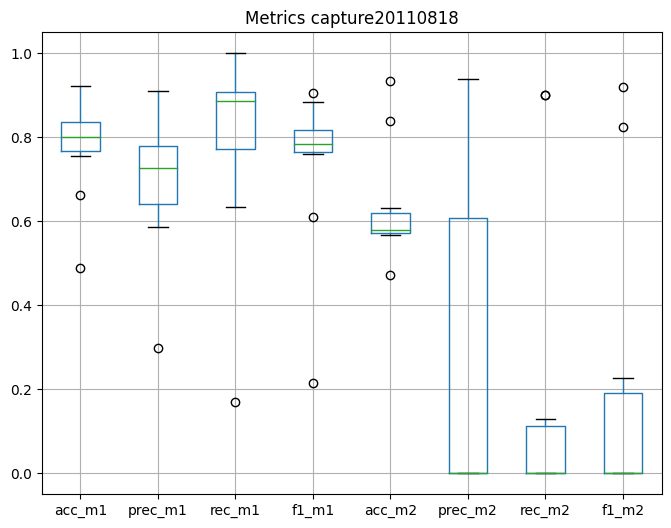

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df_metrics_test1.boxplot(column=['acc_m1', 'prec_m1', 'rec_m1', 'f1_m1', 'acc_m2', 'prec_m2', 'rec_m2', 'f1_m2'], figsize=(8, 6))
plt.title('Metrics capture20110818')
plt.show()



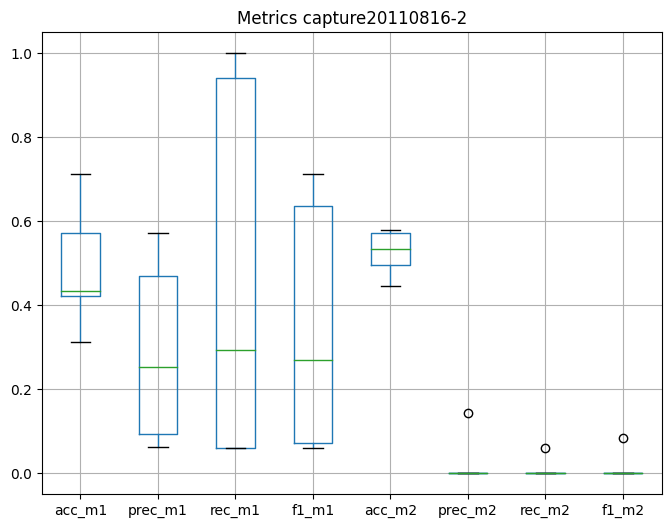

In [ ]:
plt.figure(figsize=(8,6))
df_metrics_test2.boxplot(column=['acc_m1', 'prec_m1', 'rec_m1', 'f1_m1', 'acc_m2', 'prec_m2', 'rec_m2', 'f1_m2'], figsize=(8, 6))
plt.title('Metrics capture20110816-2')
plt.show()


In [1]:
import pandas as pd
df_losses_m1 = pd.read_csv("/content/losses_m1.csv").iloc[:,1:]
df_losses_m2 = pd.read_csv("/content/losses_m2.csv").iloc[:,1:]

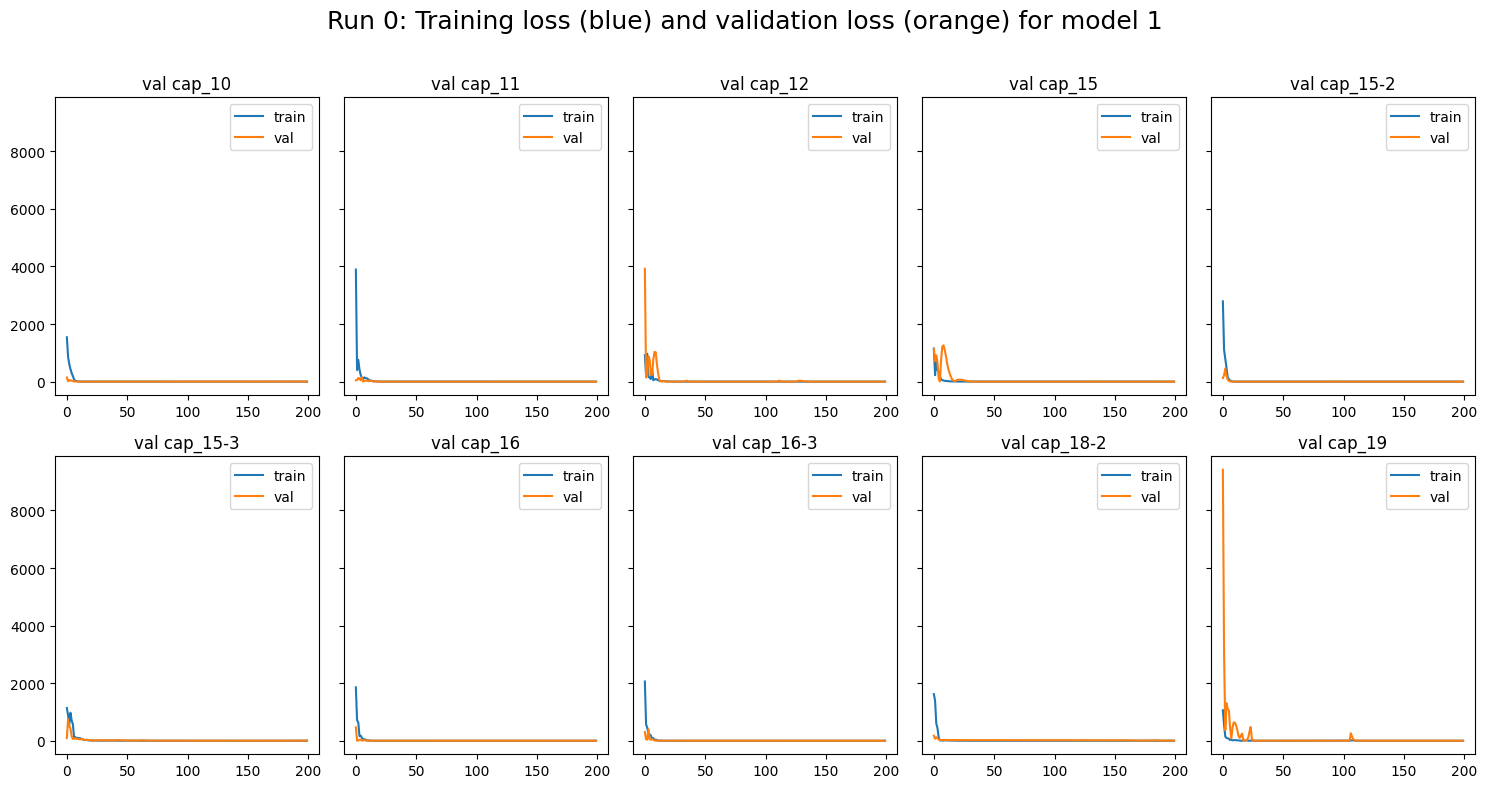

In [7]:
import matplotlib.pyplot as plt

cap_names = ["10", "11", "12", "15", "15-2", "15-3", "16", "16-3", "18-2", "19"] # excluyo 18 (test1), 16-2 (test2) y 17 (captura originalmente apartada para testear)


# Configurar la grilla de 10 plots (2 filas x 5 columnas)
fig, axs = plt.subplots(2, 5, figsize=(15, 8), sharey=True)

# Contador de "runs" para los títulos
run_counter = 0

# Iterar sobre cada par de columnas (0-1, 2-3, ...)
for i in range(2):
    for j in range(5):
        # Índices de las columnas a graficar
        col1 = (run_counter * 2)
        col2 = col1 + 1

        # Graficar los valores de las columnas col1 y col2 vs range(200)
        axs[i, j].plot(range(200), df_losses_m1.iloc[:, col1], label='train')
        axs[i, j].plot(range(200), df_losses_m1.iloc[:, col2], label='val')

        # Añadir título y leyenda
        axs[i, j].set_title(f'val cap_{cap_names[j+i*5]}')
        axs[i, j].legend()

        # Incrementar el contador de "runs"
        run_counter += 1

fig.suptitle("Run 0: Training loss (blue) and validation loss (orange) for model 1\n", fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()

In [8]:
import pandas as pd
df_metrics_test1 = pd.read_csv("/content/metrics_t1.csv").iloc[:,1:]
df_metrics_test2 = pd.read_csv("/content/metrics_t2.csv").iloc[:,1:]

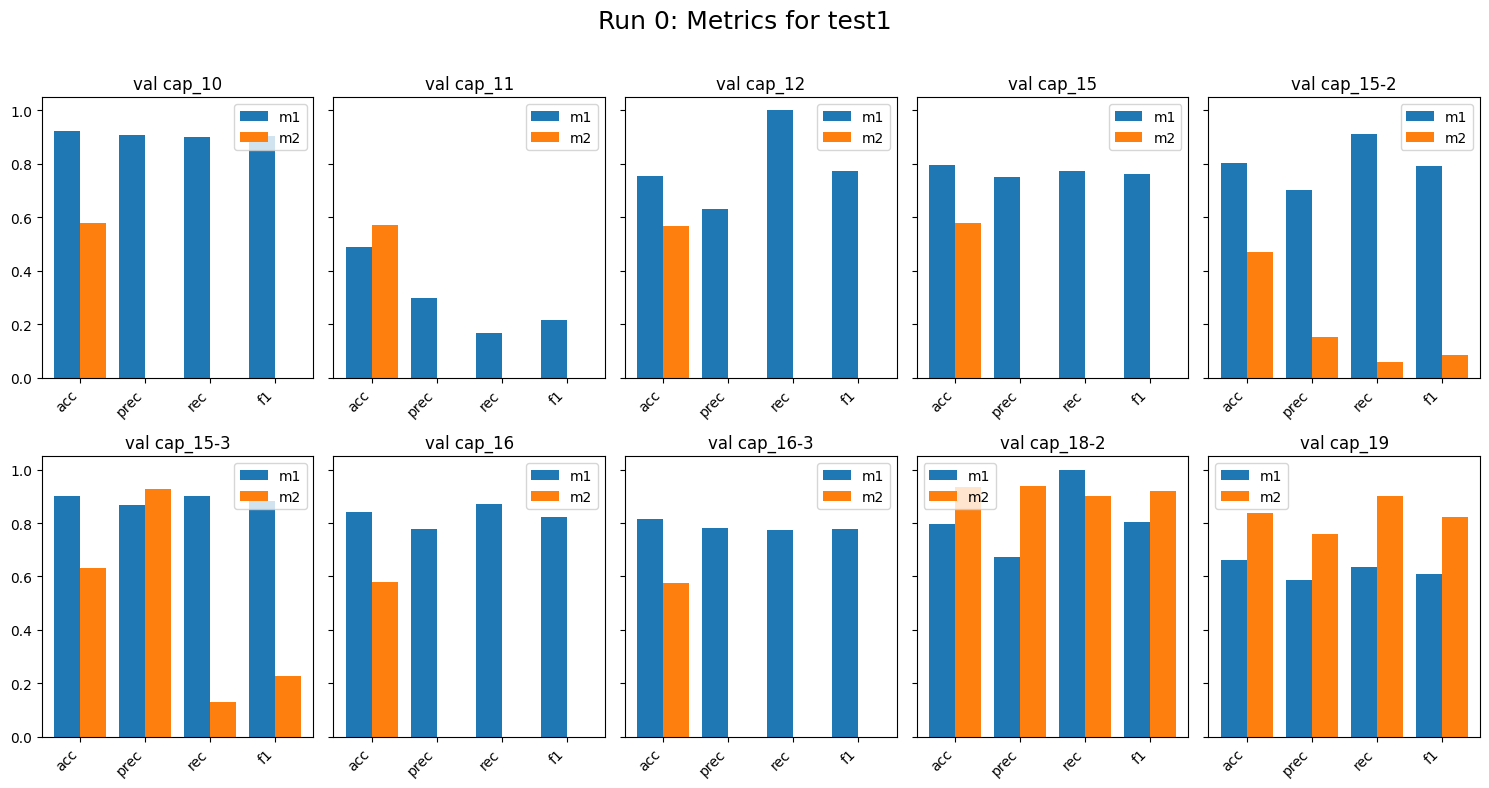

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Configurar la grilla de 10 plots (2 filas x 5 columnas)
fig, axs = plt.subplots(2, 5, figsize=(15, 8), sharey=True)

# Nombres para los xticks (las 4 comparaciones)
xtick_labels = ['acc', 'prec', 'rec', 'f1']

# Iterar sobre cada fila del DataFrame
for idx, row in enumerate(df_metrics_test1.iterrows()):
    i, j = divmod(idx, 5)  # Calcular el índice para las subplots (filas y columnas)

    # Extraer los valores de cada fila para graficar
    group_1 = row[1].iloc[[1, 2, 3, 4]]
    group_2 = row[1].iloc[[6, 7, 8, 9]]

    # Crear el gráfico de barras comparando los grupos
    axs[i, j].bar(np.arange(4) - 0.2, group_1, width=0.4, label='m1')
    axs[i, j].bar(np.arange(4) + 0.2, group_2, width=0.4, label='m2')

    # Añadir título, xticks y leyenda
    axs[i, j].set_title(f'val cap_{cap_names[j+i*5]}')
    axs[i, j].set_xticks(np.arange(4))  # Colocar los xticks en las posiciones correctas
    axs[i, j].set_xticklabels(xtick_labels, rotation=45, ha='right')  # Colocar los nombres de los xticks
    axs[i, j].legend()

#axs[0,0].legend()

fig.suptitle("Run 0: Metrics for test1\n", fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()

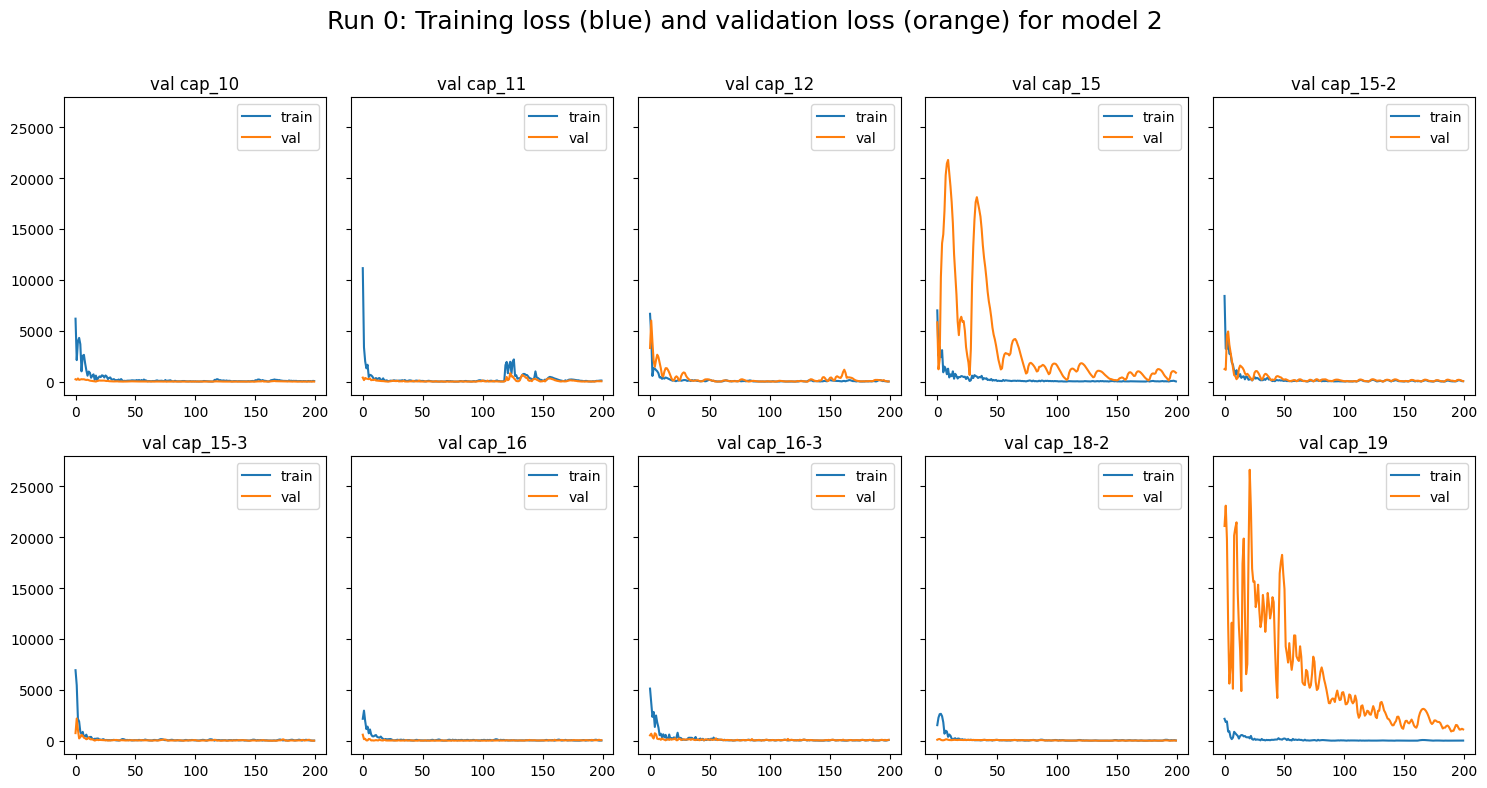

In [11]:
import matplotlib.pyplot as plt


# Configurar la grilla de 10 plots (2 filas x 5 columnas)
fig, axs = plt.subplots(2, 5, figsize=(15, 8), sharey=True)

# Contador de "runs" para los títulos
run_counter = 0

# Iterar sobre cada par de columnas (0-1, 2-3, ...)
for i in range(2):
    for j in range(5):
        # Índices de las columnas a graficar
        col1 = (run_counter * 2)
        col2 = col1 + 1

        # Graficar los valores de las columnas col1 y col2 vs range(200)
        axs[i, j].plot(range(200), df_losses_m2.iloc[:, col1], label='train')
        axs[i, j].plot(range(200), df_losses_m2.iloc[:, col2], label='val')

        # Añadir título y leyenda
        axs[i, j].set_title(f'val cap_{cap_names[j+i*5]}')
        axs[i, j].legend()

        # Incrementar el contador de "runs"
        run_counter += 1

fig.suptitle("Run 0: Training loss (blue) and validation loss (orange) for model 2\n", fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()

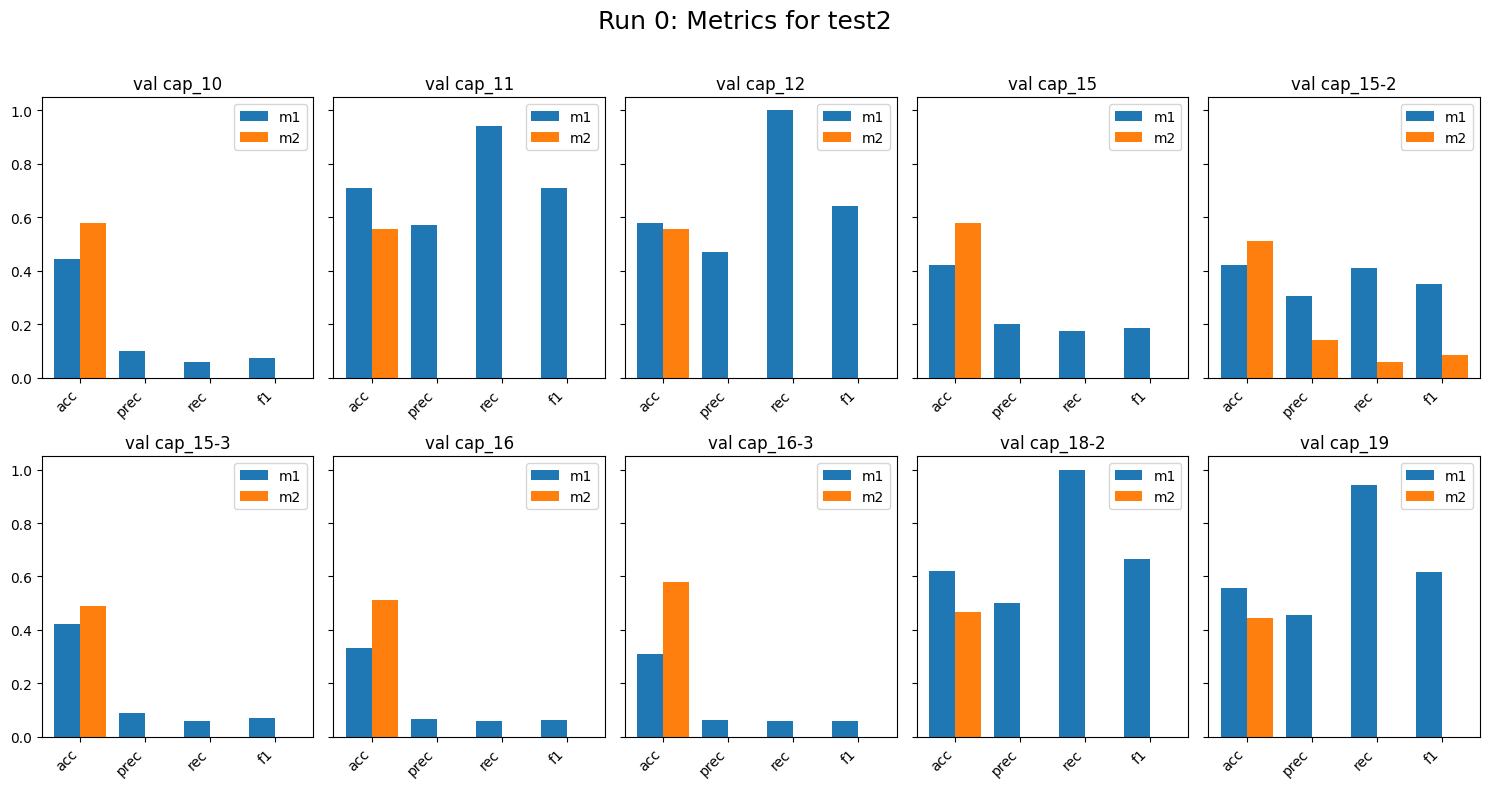

In [12]:
# Configurar la grilla de 10 plots (2 filas x 5 columnas)
fig, axs = plt.subplots(2, 5, figsize=(15, 8), sharey=True)

# Nombres para los xticks (las 4 comparaciones)
xtick_labels = ['acc', 'prec', 'rec', 'f1']

# Iterar sobre cada fila del DataFrame
for idx, row in enumerate(df_metrics_test2.iterrows()):
    i, j = divmod(idx, 5)  # Calcular el índice para las subplots (filas y columnas)

    # Extraer los valores de cada fila para graficar
    group_1 = row[1].iloc[[1, 2, 3, 4]]
    group_2 = row[1].iloc[[6, 7, 8, 9]]

    # Crear el gráfico de barras comparando los grupos
    axs[i, j].bar(np.arange(4) - 0.2, group_1, width=0.4, label='m1')
    axs[i, j].bar(np.arange(4) + 0.2, group_2, width=0.4, label='m2')

    # Añadir título, xticks y leyenda
    axs[i, j].set_title(f'val cap_{cap_names[j+i*5]}')
    axs[i, j].set_xticks(np.arange(4))  # Colocar los xticks en las posiciones correctas
    axs[i, j].set_xticklabels(xtick_labels, rotation=45, ha='right')  # Colocar los nombres de los xticks
    axs[i, j].legend()

#axs[0,0].legend()

fig.suptitle("Run 0: Metrics for test2\n", fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()